In [1]:
import os
import time
import itertools
import pickle
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


# ============================================================
# Configuration
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
lr = 2e-4
train_epoch = 50

latent_dim = 100
num_classes = 10
image_size = 28
image_dim = image_size * image_size

result_root = "MNIST_cGAN_standalone"
fixed_result_dir = os.path.join(result_root, "Fixed_results")
os.makedirs(result_root, exist_ok=True)
os.makedirs(fixed_result_dir, exist_ok=True)


# ============================================================
# GAN networks
# ============================================================
from networks.GAN_network import Discriminator, Generator

# ============================================================
# Fixed noise for visualization
# ============================================================
temp_z = torch.rand(10, latent_dim)
fixed_z = temp_z.clone()
fixed_y = torch.zeros(10, 1)

for i in range(9):
    fixed_z = torch.cat([fixed_z, temp_z], dim=0)
    temp = torch.ones(10, 1) + i
    fixed_y = torch.cat([fixed_y, temp], dim=0)

fixed_z = fixed_z.to(device)

fixed_y_label = torch.zeros(100, 10)
fixed_y_label.scatter_(1, fixed_y.long(), 1)
fixed_y_label = fixed_y_label.to(device)


# ============================================================
# Visualization
# ============================================================
@torch.no_grad()
def show_result(num_epoch, save=False, path="result.png"):
    G.eval()
    test_images = G(fixed_z, fixed_y_label)
    G.train()

    fig, ax = plt.subplots(10, 10, figsize=(5, 5))
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    for i, j in itertools.product(range(10), range(10)):
        ax[i, j].axis("off")

    for k in range(100):
        i = k // 10
        j = k % 10
        img = test_images[k].cpu().view(28, 28).numpy()
        ax[i, j].imshow(img, cmap="gray", vmin=-1, vmax=1)

    #fig.text(0.5, 0.04, f"Epoch {num_epoch}", ha="center")

    if save:
        plt.savefig(path)
    plt.close()


def show_train_hist(hist, save=False, path="train_hist.png"):
    x = range(len(hist["D_losses"]))

    plt.plot(x, hist["D_losses"], label="D_loss")
    plt.plot(x, hist["G_losses"], label="G_loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    if save:
        plt.savefig(path)
    plt.close()


# ============================================================
# Dataset
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load full dataset
full_dataset = datasets.MNIST("data", train=True, download=True, transform=transform)

# Get indices of only labels 0 and 1
indices = [i for i, (_, label) in enumerate(full_dataset) if label in [0, 1]]

# Create subset
filtered_dataset = Subset(full_dataset, indices)

# DataLoader
train_loader = DataLoader(
    full_dataset,
    batch_size=batch_size,
    shuffle=True
)


# ============================================================
# Setup
# ============================================================
G = Generator(hidden_dim=200).to(device)
D = Discriminator(hidden_dim=200).to(device)

G.weight_init(0, 0.02)
D.weight_init(0, 0.02)

criterion = nn.BCELoss()

G_optimizer = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
D_optimizer = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))


train_hist = {"D_losses": [], "G_losses": [], "per_epoch_ptimes": []}


# ============================================================
# Training
# ============================================================
print("training start!")
start_time = time.time()

for epoch in range(train_epoch):
    D_losses, G_losses = [], []

    if epoch == 29 or epoch == 39:
        G_optimizer.param_groups[0]["lr"] /= 10
        D_optimizer.param_groups[0]["lr"] /= 10
        print("learning rate change!")

    epoch_start_time = time.time()

    for x_real, y_real in train_loader:
        mini_batch = x_real.size(0)

        x_real = x_real.view(mini_batch, -1).to(device)

        y_real_onehot = torch.zeros(mini_batch, 10, device=device)
        y_real_onehot.scatter_(1, y_real.view(-1, 1).to(device), 1)

        real_target = torch.ones(mini_batch, device=device)
        fake_target = torch.zeros(mini_batch, device=device)

        # ---------------- D ----------------
        D.zero_grad()

        D_real = D(x_real, y_real_onehot).squeeze()
        D_real_loss = criterion(D_real, real_target)

        z = torch.rand(mini_batch, latent_dim, device=device)
        y_fake = torch.randint(0, 10, (mini_batch, 1), device=device)

        y_fake_onehot = torch.zeros(mini_batch, 10, device=device)
        y_fake_onehot.scatter_(1, y_fake, 1)

        fake_images = G(z, y_fake_onehot)
        D_fake = D(fake_images, y_fake_onehot).squeeze()
        D_fake_loss = criterion(D_fake, fake_target)

        D_loss = D_real_loss + D_fake_loss
        D_loss.backward()
        D_optimizer.step()

        # ---------------- G ----------------
        G.zero_grad()

        z = torch.rand(mini_batch, latent_dim, device=device)
        y_fake = torch.randint(0, 10, (mini_batch, 1), device=device)

        y_fake_onehot = torch.zeros(mini_batch, 10, device=device)
        y_fake_onehot.scatter_(1, y_fake, 1)

        fake_images = G(z, y_fake_onehot)
        D_fake = D(fake_images, y_fake_onehot).squeeze()

        G_loss = criterion(D_fake, real_target)
        G_loss.backward()
        G_optimizer.step()

        D_losses.append(D_loss.item())
        G_losses.append(G_loss.item())

    print(f"[{epoch+1}/{train_epoch}] D: {sum(D_losses)/len(D_losses):.3f}, G: {sum(G_losses)/len(G_losses):.3f}")

    show_result(epoch + 1, save=True, path=os.path.join(fixed_result_dir, f"{epoch+1}.png"))

end_time = time.time()
print(f"Training finished in {end_time - start_time:.2f} seconds")

torch.save(G.state_dict(), os.path.join(result_root, "generator.pth"))
torch.save(D.state_dict(), os.path.join(result_root, "discriminator.pth"))

show_train_hist(train_hist, save=True, path=os.path.join(result_root, "loss.png"))

training start!
[1/50] D: 0.958, G: 1.117
[2/50] D: 0.556, G: 1.775
[3/50] D: 0.452, G: 2.124
[4/50] D: 0.491, G: 2.227
[5/50] D: 0.527, G: 2.206
[6/50] D: 0.589, G: 2.147
[7/50] D: 0.576, G: 2.212
[8/50] D: 0.609, G: 2.165
[9/50] D: 0.637, G: 2.095
[10/50] D: 0.698, G: 1.980
[11/50] D: 0.616, G: 2.156
[12/50] D: 0.574, G: 2.348
[13/50] D: 0.515, G: 2.489
[14/50] D: 0.680, G: 2.083
[15/50] D: 0.680, G: 2.007
[16/50] D: 0.673, G: 1.953
[17/50] D: 0.680, G: 1.994
[18/50] D: 0.696, G: 1.918
[19/50] D: 0.685, G: 1.960
[20/50] D: 0.656, G: 1.992
[21/50] D: 0.666, G: 2.033
[22/50] D: 0.622, G: 2.112
[23/50] D: 0.627, G: 2.060
[24/50] D: 0.621, G: 2.075
[25/50] D: 0.599, G: 2.145
[26/50] D: 0.604, G: 2.101
[27/50] D: 0.588, G: 2.172
[28/50] D: 0.609, G: 2.114
[29/50] D: 0.514, G: 2.350
learning rate change!
[30/50] D: 0.480, G: 1.887
[31/50] D: 0.424, G: 1.974
[32/50] D: 0.423, G: 2.009
[33/50] D: 0.389, G: 2.130
[34/50] D: 0.372, G: 2.141
[35/50] D: 0.386, G: 2.170
[36/50] D: 0.392, G: 2.155

In [4]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import datasets, transforms


# ============================================================
# Configuration
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100
num_classes = 10
image_dim = 28 * 28

generator_path = "MNIST_cGAN_standalone/generator.pth"
discriminator_path = "MNIST_cGAN_standalone/discriminator.pth"

num_per_class = 6000
batch_size_gen = 500

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)


# ============================================================
# Model definitions
# Must match training code exactly
# ============================================================
from networks.GAN_network import Discriminator, Generator

# ============================================================
# Helper
# ============================================================
def labels_to_onehot(labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    y = torch.zeros(labels.size(0), num_classes, device=labels.device)
    y.scatter_(1, labels.view(-1, 1), 1.0)
    return y


# ============================================================
# Load trained models
# ============================================================
G = Generator().to(device)
D = Discriminator().to(device)

G.load_state_dict(torch.load(generator_path, map_location=device))
D.load_state_dict(torch.load(discriminator_path, map_location=device))

G.eval()
D.eval()

print("Loaded generator and discriminator.")


# ============================================================
# Generate synthetic dataset: 60,000 images total
# 6,000 per class
# ============================================================
@torch.no_grad()
def generate_dataset(generator, num_per_class, latent_dim, num_classes, batch_size, device):
    all_images = []
    all_labels = []

    for cls in range(num_classes):
        cls_images = []
        cls_labels = []

        n_generated = 0
        while n_generated < num_per_class:
            current_batch = min(batch_size, num_per_class - n_generated)

            z = torch.rand(current_batch, latent_dim, device=device)
            labels = torch.full((current_batch,), cls, dtype=torch.long, device=device)
            labels_onehot = labels_to_onehot(labels, num_classes)

            fake_imgs = generator(z, labels_onehot)  # range approx [-1, 1]

            cls_images.append(fake_imgs.cpu())
            cls_labels.append(labels.cpu())

            n_generated += current_batch

        cls_images = torch.cat(cls_images, dim=0)
        cls_labels = torch.cat(cls_labels, dim=0)

        all_images.append(cls_images)
        all_labels.append(cls_labels)

        print(f"Generated class {cls}: {cls_images.shape[0]} samples")

    all_images = torch.cat(all_images, dim=0)   # [60000, 784]
    all_labels = torch.cat(all_labels, dim=0)   # [60000]

    return all_images, all_labels


generated_images, generated_labels = generate_dataset(
    generator=G,
    num_per_class=num_per_class,
    latent_dim=latent_dim,
    num_classes=num_classes,
    batch_size=batch_size_gen,
    device=device
)

print("Generated dataset shape:", generated_images.shape)
print("Generated labels shape:", generated_labels.shape)


# ============================================================
# Scale generated samples to zero mean and unit variance
# ============================================================
gen_mean = generated_images.mean()
gen_std = generated_images.std()

generated_images = (generated_images - gen_mean) / (gen_std + 1e-8)

print(f"Generated data standardized: mean={generated_images.mean().item():.6f}, std={generated_images.std().item():.6f}")


# ============================================================
# Load original MNIST and precomputed UMAP
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])

mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

X_real = torch.stack(
    [mnist_train[i][0] for i in tqdm(range(len(mnist_train)), desc="Loading MNIST")]
)
y_real = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])

# convert to numpy
X_real = X_real.numpy()
y_real = y_real.numpy()

# load fitted UMAP and saved embedding
reducer = joblib.load("umap_model.pkl")
X_real_umap = np.load("mnist_umap_embedding.npy")

print("Loaded original dataset, fitted UMAP model, and saved UMAP embedding.")
print("Real dataset shape:", X_real.shape)
print("Real labels shape:", y_real.shape)
print("Saved embedding shape:", X_real_umap.shape)


# ============================================================
# Convert generated data to numpy
# ============================================================
X_gen = generated_images.numpy()
y_gen = generated_labels.numpy()

print("Generated dataset shape for projection:", X_gen.shape)
print("Generated labels shape:", y_gen.shape)


# ============================================================
# Project generated data into existing UMAP space
# ============================================================
print("Projecting generated dataset into fitted UMAP space...")
X_gen_umap = reducer.transform(X_gen)



Loaded generator and discriminator.
Generated class 0: 6000 samples
Generated class 1: 6000 samples
Generated class 2: 6000 samples
Generated class 3: 6000 samples
Generated class 4: 6000 samples
Generated class 5: 6000 samples
Generated class 6: 6000 samples
Generated class 7: 6000 samples
Generated class 8: 6000 samples
Generated class 9: 6000 samples
Generated dataset shape: torch.Size([60000, 784])
Generated labels shape: torch.Size([60000])
Generated data standardized: mean=-0.000000, std=1.000000


Loading MNIST: 100%|██████████| 60000/60000 [00:04<00:00, 12657.22it/s]
/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded original dataset, fitted UMAP model, and saved UMAP embedding.
Real dataset shape: (60000, 784)
Real labels shape: (60000,)
Saved embedding shape: (60000, 2)
Generated dataset shape for projection: (60000, 784)
Generated labels shape: (60000,)
Projecting generated dataset into fitted UMAP space...


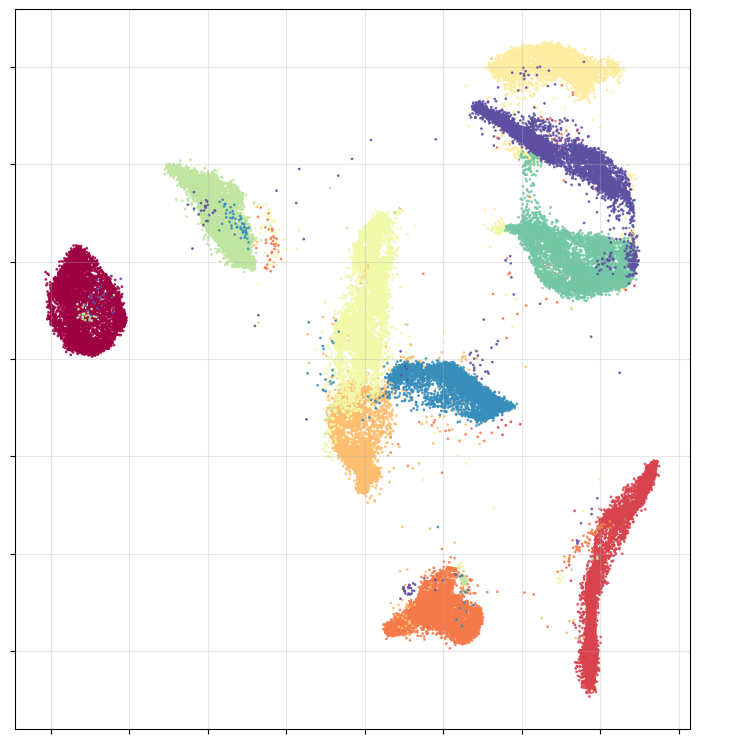

In [5]:

# --- Plot ---
fig = plt.figure(figsize=(9, 9))

# Main plot axis (fixed size)
ax = fig.add_axes([0.1, 0.1, 0.75, 0.8])

# Reserved space for colorbar (always exists!)
cax = fig.add_axes([0.88, 0.1, 0.03, 0.8])

# Plot generated samples
scatter_gen = ax.scatter(
    X_gen_umap[:, 0], X_gen_umap[:, 1],
    c=y_gen, cmap="Spectral", s=1, alpha=0.8, label="Generated"
)

"""scatter_mnist = ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=1, alpha=0.8, label="MNIST"
)"""


# Remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True, alpha=0.3)

# Toggle this flag
use_colorbar = False

if use_colorbar:
    cbar = plt.colorbar(
        scatter_gen,
        cax=cax,
        boundaries=np.arange(11) - 0.5,
        ticks=np.arange(10)
    )
    cbar.set_label("Predicted Label")
else:
    # Keep layout identical, just hide colorbar axis
    cax.axis("off")

plt.show()

In [6]:
from networks.BP_network import *
from src.dataloaders import *
from src.trainers import Trainer, TrainerDFCL
from src.utils import *
from networks.DFC_network import *


In [7]:
config = {
        "layers": [784,200,200,200,10],
        "num_classes": 10,
        "lr": 1e-4, 
        "lr_fb": 1e-4, 
        "batch_size": 100,
        "batch_size_gen": 30000,
        "epochs": 50,
        "mode": "di",
        "num_workers": 0,
        "loss_fn": "ce",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "activation_fun": "Tanh",
        "device": "cuda",
        "output_dir": "./outputs",
        "seed": 1337,
        "taus": [0.02, 0.02, 0.02, 0.016, 0.01],
        "target_lr": 1,#1e-2,       # Updated to optimal value
        "alpha_di": 0.0017,        # 1/tau for tau=0.2
        "dt_di": 0.02,         # Time step
        "time_constant_ratio": 0.2,  # tau
        "tmax_di":10,
        "k_p": 2.0,             # Optimal for G=1, tau=0.2
        "eps": 1e-4,
        "save": True,
        "flatten_imgs": "default",
        "num_tasks": 2,
        "classes_per_task": 5,
        "setting": "full",
        "first_task_only": False,
}

config = dotdict(config)

In [8]:
# Load data
train_loader, test_loader = MNIST(config=config).get_dataloaders()

In [ ]:
model = DFCL_network_multilayer(config)

# Load the trained weights
checkpoint = torch.load("/cluster/raid/home/sschwartz/Equilibrium-Fisher-Control/outputs/DFCL_y_r_r_u_next_deriv_FF_first_low_thresh/model.pt", map_location=torch.device(config.device))
model.load_state_dict(checkpoint)

# Set model to evaluation mode
model.eval()

print("Loaded DFC_network successfully!")

[DFCL] Feedback connections initialized.
Loaded DFC_network successfully!


In [ ]:
(train_loss, train_acc), (test_loss, test_acc) = evaluate(model, train_loader, test_loader, device=model.device)

In [9]:
from torch.utils.data import TensorDataset, ConcatDataset, DataLoader
from torchvision import datasets, transforms

sm = torch.nn.Softmax(dim=1)

y_l = torch.nn.functional.one_hot(torch.tensor(y_gen)).float()
#y_l = (sm(model(torch.tensor(X_gen))).clone().detach())
generated_dataset1 = TensorDataset(torch.tensor(X_gen), (y_l))


# Combine them
full_dataset = ConcatDataset([generated_dataset1])

# Build dataloader
g = torch.Generator(device="cuda")
g.manual_seed(42)

train_loader2 = DataLoader(
    full_dataset,
    batch_size=100,
    shuffle=True,
    generator=g
)


In [10]:
# Train model
config2 = config.copy()
config2["epochs"] = 50
config2["layers"] = [784,200,200,200,10]
config2["loss_fn"] = "ce"
config2["save"] = False
config2 = dotdict(config2)
model2 = BP_network(config=config2)

"""trainer2 = Trainer(model2, train_loader, test_loader, config)
trainer2.train()"""
trainer3 = Trainer(model2, train_loader2, test_loader, config2)
trainer3.train()


Training:
 - layers: [784, 200, 200, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 30000
 - epochs: 50
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 10
 - k_p: 2.0
 - eps: 0.0001
 - save: False
 - flatten_imgs: default
 - num_tasks: 2
 - classes_per_task: 5
 - setting: full
 - first_task_only: False
 - in_channels: 1
 - model: BP_network



				Epoch: 001, Train loss: 0.1436 & test loss: 0.7878 & accuracy: 74.72


				Epoch: 002, Train loss: 0.0043 & test loss: 0.7894 & accuracy: 75.20


				Epoch: 003, Train loss: 0.0016 & test loss: 0.8058 & accuracy: 75.64


				Epoch: 004, Train loss: 0.0008 & test loss: 0.8140 & accuracy: 75.94


...

				Epoch: 026, Train loss: 0.0000 & test loss: 1.1967 & accuracy: 75.46


				Epoch: 027, Train loss: 0.0000 & test loss: 1.2111 & accuracy: 75.46


				Epoch: 028, Train loss: 0.0000 & test loss: 1.2266 & accuracy: 75.40


Training epoch 029/50:   0%|          | 0/600 [00:00<?, ?batch/s]

KeyboardInterrupt: 

In [18]:
import torch
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance


def _prepare_batch_for_fid(
    x: torch.Tensor,
    mean: float = 0.1307,
    std: float = 0.3081,
    flattened: bool = True,
    image_size: tuple = (28, 28),
) -> torch.Tensor:
    """
    Prepare a batch for Inception-based FID.

    Input can be:
      - [B, 784] for flattened grayscale MNIST
      - [B, H, W]
      - [B, 1, H, W]
      - [B, 3, H, W]

    Assumes the input is normalized with:
        x_norm = (x - mean) / std

    Returns:
        Tensor of shape [B, 3, H, W], float32, values in [0, 1]
    """
    if not isinstance(x, torch.Tensor):
        x = torch.as_tensor(x)

    x = x.float()

    # Case 1: flattened images [B, 784]
    if x.ndim == 2:
        if not flattened:
            raise ValueError(f"Got flattened input of shape {tuple(x.shape)}, but flattened=False")
        h, w = image_size
        if x.shape[1] != h * w:
            raise ValueError(f"Expected flattened dimension {h*w}, got {x.shape[1]}")
        x = x.view(x.shape[0], 1, h, w)

    # Case 2: [B, H, W] -> [B, 1, H, W]
    elif x.ndim == 3:
        x = x.unsqueeze(1)

    # Case 3: already [B, C, H, W]
    elif x.ndim != 4:
        raise ValueError(f"Expected input with 2, 3, or 4 dims, got shape {tuple(x.shape)}")

    # Undo normalization: x = x_norm * std + mean
    x = x * std + mean

    # Clamp to valid image range
    x = x.clamp(0.0, 1.0)

    # Convert grayscale to 3 channels
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)
    elif x.shape[1] != 3:
        raise ValueError(f"Expected 1 or 3 channels, got {x.shape[1]}")

    return x


@torch.no_grad()
def compute_fid_between_dataloaders(
    loader_a: DataLoader,
    loader_b: DataLoader,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    mean: float = 0.1307,
    std: float = 0.3081,
    flattened: bool = True,
    image_size: tuple = (28, 28),
) -> float:
    """
    Compute FID between two datasets exposed as DataLoaders.

    Assumes each batch is either:
      - images
      - (images, labels)
      - [images, labels]
    """
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=True
    ).to(device)

    fid.set_dtype(torch.float64)

    for batch in loader_a:
        imgs = batch[0] if isinstance(batch, (tuple, list)) else batch
        imgs = _prepare_batch_for_fid(
            imgs,
            mean=mean,
            std=std,
            flattened=flattened,
            image_size=image_size
        ).to(device)
        fid.update(imgs, real=True)
        
    print("Train loader A done")

    for batch in loader_b:
        imgs = batch[0] if isinstance(batch, (tuple, list)) else batch
        imgs = _prepare_batch_for_fid(
            imgs,
            mean=mean,
            std=std,
            flattened=flattened,
            image_size=image_size
        ).to(device)
        fid.update(imgs, real=False)

    print("Train loader B done")
        

    score = fid.compute()
    return float(score.item())

In [21]:

fid_value = compute_fid_between_dataloaders(train_loader, train_loader2)
print(f"FID: {fid_value:.4f}")

Train loader A done
Train loader B done
FID: 182.9563
